In [8]:
"""
Descarga de gasoductos para análisis de localización planta biometano
Provincia de Huesca

Fuente:
  OpenStreetMap (Overpass) — gasoductos mapeados en OSM

Output: gasoductos_huesca.gpkg
"""

import geopandas as gpd
import requests
import json
import time
from pathlib import Path
from shapely.geometry import shape, LineString, box
from shapely.ops import unary_union

# ─────────────────────────────────────────────────────────
# CONFIGURACIÓN  (sin rutas absolutas — todo en el directorio actual)
# ─────────────────────────────────────────────────────────
# Rutas relativas a la raíz del repo: notebook está en notebooks/01_download/
OUTPUT_DIR  = Path("../../data/raw/02_gasoductos")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_GPKG = OUTPUT_DIR / "gasoductos_huesca.gpkg"

CRS_UTM = "EPSG:25830"

# BBox de Huesca en WGS84 (miny, minx, maxy, maxx) — orden Overpass
BBOX_OVERPASS = "41.347806,-0.934168,42.921806,0.771832"


# ─────────────────────────────────────────────────────────
# 0. DESCARGA DEL LÍMITE DE HUESCA DESDE OSM (Overpass)
# ─────────────────────────────────────────────────────────
def descargar_limite_huesca():
    """
    Descarga el polígono de la provincia de Huesca directamente
    desde la API de Overpass (OSM), sin necesidad de archivo físico.
    """
    print("Descargando límite provincial de Huesca desde OSM...")

    query = """
    [out:json][timeout:60];
    relation["name"="Huesca"]["admin_level"="6"]["boundary"="administrative"];
    out geom;
    """
    headers = {"User-Agent": "biometano-huesca-research/1.0 (academic)"}
    endpoints = [
        "https://overpass-api.de/api/interpreter",
        "https://overpass.kumi.systems/api/interpreter",
    ]

    for url in endpoints:
        try:
            r = requests.post(url, data={"data": query}, headers=headers, timeout=90)
            if r.status_code == 200:
                data = r.json()
                elements = data.get("elements", [])
                if elements:
                    # Intentar construir el polígono desde los miembros
                    import shapely.ops as sops
                    from shapely.geometry import MultiLineString, Polygon

                    lines = []
                    for el in elements:
                        if "members" in el:
                            for m in el["members"]:
                                if m.get("type") == "way" and "geometry" in m:
                                    coords = [(pt["lon"], pt["lat"]) for pt in m["geometry"]]
                                    if len(coords) >= 2:
                                        lines.append(LineString(coords))

                    if lines:
                        merged = sops.linemerge(lines)
                        polys = list(sops.polygonize(merged))
                        if polys:
                            from shapely.geometry import MultiPolygon
                            geom = MultiPolygon(polys) if len(polys) > 1 else polys[0]
                            gdf_h = gpd.GeoDataFrame(
                                [{"nombre": "Huesca", "geometry": geom}],
                                crs="EPSG:4326"
                            ).to_crs(CRS_UTM)
                            print(f"  Límite descargado correctamente ({url})")
                            return gdf_h

        except Exception as e:
            print(f"  {url} falló: {e}")
            time.sleep(3)

    # Fallback: bbox hardcoded como polígono rectangular
    print("  Usando bbox rectangular como límite (fallback)")
    from shapely.geometry import box as sbox
    geom = sbox(-0.934168, 41.347806, 0.771832, 42.921806)
    return gpd.GeoDataFrame(
        [{"nombre": "Huesca", "geometry": geom}],
        crs="EPSG:4326"
    ).to_crs(CRS_UTM)


# ─────────────────────────────────────────────────────────
# 1. DESCARGA OSM — GASODUCTOS
# ─────────────────────────────────────────────────────────
def descargar_osm_gasoductos():
    """
    Descarga gasoductos de OpenStreetMap via Overpass API.
    Etiquetas: man_made=pipeline + substance=gas/natural_gas
    """
    print("Descargando gasoductos OSM...")

    query = f"""
    [out:json][timeout:120];
    (
      way["man_made"="pipeline"]["substance"~"gas|natural_gas"]({BBOX_OVERPASS});
      way["pipeline"="gas"]({BBOX_OVERPASS});
      relation["man_made"="pipeline"]["substance"~"gas|natural_gas"]({BBOX_OVERPASS});
    );
    out geom;
    """

    endpoints = [
        "https://overpass-api.de/api/interpreter",
        "https://overpass.kumi.systems/api/interpreter",
    ]
    headers = {"User-Agent": "biometano-huesca-research/1.0 (academic)"}

    for url in endpoints:
        try:
            r = requests.post(url, data={"data": query},
                              headers=headers, timeout=150)
            if r.status_code == 200:
                elements = r.json().get("elements", [])
                print(f"  {len(elements)} elementos encontrados ({url})")

                lineas = []
                for el in elements:
                    if "geometry" in el:
                        coords = [(pt["lon"], pt["lat"])
                                  for pt in el["geometry"]]
                        if len(coords) >= 2:
                            tags = el.get("tags", {})
                            lineas.append({
                                "osm_id":    el.get("id"),
                                "nombre":    tags.get("name", ""),
                                "operador":  tags.get("operator", ""),
                                "substance": tags.get("substance", "gas"),
                                "tipo":      tags.get("pipeline", ""),
                                "presion":   tags.get("pressure", ""),
                                "fuente":    "OSM",
                                "geometry":  LineString(coords)
                            })

                if lineas:
                    gdf = gpd.GeoDataFrame(lineas, crs="EPSG:4326").to_crs(CRS_UTM)
                    print(f"  {len(gdf)} tramos de gasoducto en Huesca")
                    return gdf
                else:
                    print("  Sin geometrías válidas en OSM")
                    return None

        except Exception as e:
            print(f"  {url} falló: {e}")
            time.sleep(3)

    print("  Todos los endpoints fallaron")
    return None


# ─────────────────────────────────────────────────────────
# 2. GUARDAR Y CALCULAR DISTANCIAS
# ─────────────────────────────────────────────────────────
def guardar_gasoductos(gdf_osm):
    """Guarda el GeoDataFrame de gasoductos OSM en GPKG."""
    if gdf_osm is None or len(gdf_osm) == 0:
        print("Sin gasoductos para guardar.")
        return None

    gdf_final = gpd.GeoDataFrame(gdf_osm, crs=CRS_UTM)

    gdf_final.to_file(OUTPUT_GPKG, driver="GPKG", layer="gasoductos")
    print(f"\n  GPKG guardado: {OUTPUT_GPKG}")
    print(f"  Total tramos: {len(gdf_final)}")
    return gdf_final


def calcular_distancia_gasoducto(gdf_granjas, gdf_gasoductos):
    """
    Añade columna 'dist_gasoducto_m' al GeoDataFrame de granjas.
    Distancia en metros desde cada granja al gasoducto más cercano.
    """
    print("\nCalculando distancias granja → gasoducto...")

    red_gas = unary_union(gdf_gasoductos.geometry)

    gdf_granjas = gdf_granjas.copy()
    gdf_granjas["dist_gasoducto_m"] = gdf_granjas.geometry.distance(red_gas).round(0)

    print(f"  Distancia media:   {gdf_granjas['dist_gasoducto_m'].mean():.0f} m")
    print(f"  Distancia mínima:  {gdf_granjas['dist_gasoducto_m'].min():.0f} m")
    print(f"  Distancia máxima:  {gdf_granjas['dist_gasoducto_m'].max():.0f} m")
    print(f"  Granjas < 5 km:    {(gdf_granjas['dist_gasoducto_m'] < 5000).sum()}")
    print(f"  Granjas < 15 km:   {(gdf_granjas['dist_gasoducto_m'] < 15000).sum()}")

    return gdf_granjas


# ─────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────
if __name__ == "__main__":

    print("\n" + "="*60)
    print("  GASODUCTOS HUESCA — DESCARGA Y ANÁLISIS (OSM)")
    print("="*60 + "\n")

    # 0. Límite de Huesca (descarga automática, sin archivo físico)
    huesca_gdf = descargar_limite_huesca()

    # 1. OSM
    gdf_osm = descargar_osm_gasoductos()

    # 2. Guardar
    gdf_gas = guardar_gasoductos(gdf_osm)

    # 3. Si tienes el gdf de granjas en memoria, calcula distancias
    # (descomenta cuando tengas gdf cargado)
    # gdf_con_dist = calcular_distancia_gasoducto(gdf, gdf_gas)
    # gdf_con_dist.to_file(OUTPUT_DIR / "granjas_con_distancias.gpkg",
    #                       driver="GPKG", layer="granjas")



  GASODUCTOS HUESCA — DESCARGA Y ANÁLISIS (OSM)

Descargando límite provincial de Huesca desde OSM...
  Límite descargado correctamente (https://overpass-api.de/api/interpreter)
Descargando gasoductos OSM...
  97 elementos encontrados (https://overpass-api.de/api/interpreter)
  97 tramos de gasoducto en Huesca

  GPKG guardado: ../../data/raw/02_gasoductos/gasoductos_huesca.gpkg
  Total tramos: 97


Tramos OSM:        46
Longitud red:      389 km
Dist. media:       12.4 km
Dist. mediana:     7.6 km
Granjas < 5 km:    813 (36.7%)
Granjas < 15 km:   1492 (67.3%)


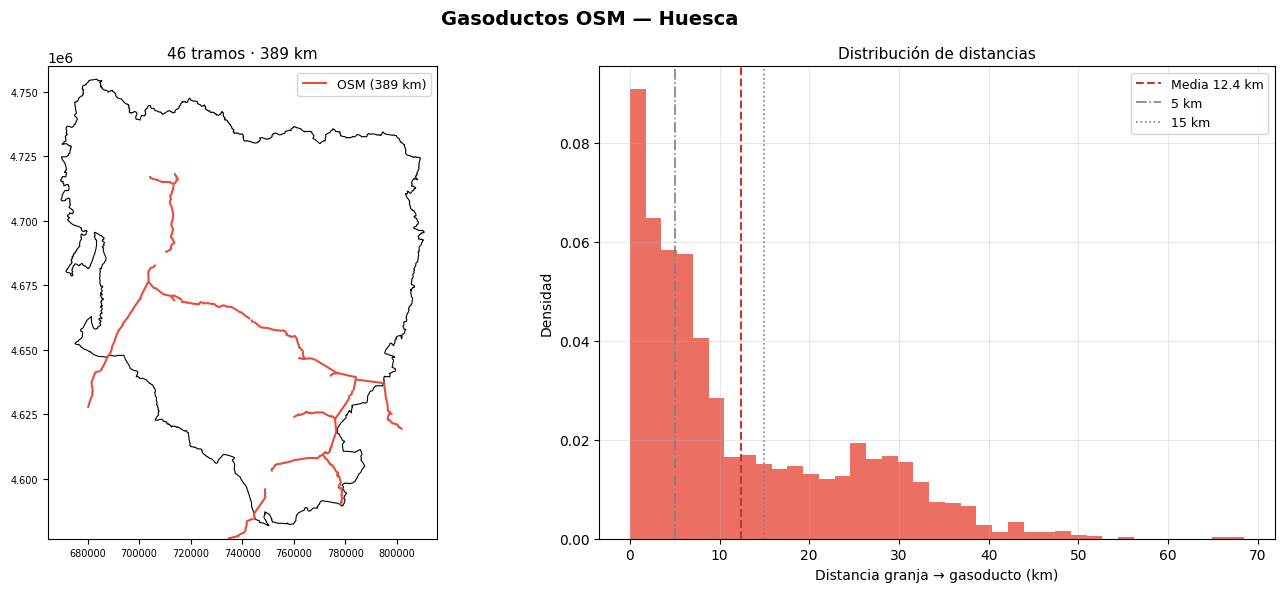

Guardado: ../../data/map/02_gasoductos/gasoductos_osm_huesca.png


In [9]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from shapely.ops import unary_union
from pathlib import Path

RAW_DIR = Path("../../data/raw/02_gasoductos")
MAP_DIR = Path("../../data/map/02_gasoductos")
RAW_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PNG = MAP_DIR / "gasoductos_osm_huesca.png"
PORCINO_DIR = Path("../../data/raw/01_ganado_porcino")
CRS_UTM = "EPSG:25830"

# Carga tu archivo de granjas (salida del notebook 01_ganado_porcino, en data/raw)
gdf_granjas = gpd.read_file(PORCINO_DIR / "clasificacion_porcino.gpkg").to_crs(CRS_UTM)

huesca  = huesca_gdf.copy()
h_union = unary_union(huesca.geometry)
h_buf   = h_union.buffer(10_000)

osm_clip = gdf_osm[gdf_osm.geometry.intersects(h_buf)].copy()
km_osm   = osm_clip.geometry.length.sum() / 1000

red_osm  = unary_union(osm_clip.geometry)
dist_osm = gdf_granjas.geometry.distance(red_osm) / 1000

print(f"Tramos OSM:        {len(osm_clip)}")
print(f"Longitud red:      {km_osm:.0f} km")
print(f"Dist. media:       {dist_osm.mean():.1f} km")
print(f"Dist. mediana:     {dist_osm.median():.1f} km")
print(f"Granjas < 5 km:    {(dist_osm < 5).sum()} ({(dist_osm < 5).mean()*100:.1f}%)")
print(f"Granjas < 15 km:   {(dist_osm < 15).sum()} ({(dist_osm < 15).mean()*100:.1f}%)")

# ── Figura ────────────────────────────────────────────────
fig, (ax_map, ax_hist) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Gasoductos OSM — Huesca", fontsize=14, fontweight="bold")

bounds = h_union.bounds
huesca.boundary.plot(ax=ax_map, color="black", linewidth=0.8)
osm_clip.plot(ax=ax_map, color="#e74c3c", linewidth=1.5, label=f"OSM ({km_osm:.0f} km)")
ax_map.set_xlim(bounds[0]-5000, bounds[2]+5000)
ax_map.set_ylim(bounds[1]-5000, bounds[3]+5000)
ax_map.set_title(f"{len(osm_clip)} tramos · {km_osm:.0f} km", fontsize=11)
ax_map.legend(fontsize=9)
ax_map.tick_params(labelsize=7)

bins = np.linspace(0, dist_osm.max(), 40)
ax_hist.hist(dist_osm, bins=bins, color="#e74c3c", alpha=0.8, density=True)
ax_hist.axvline(dist_osm.mean(),   color="#c0392b", linestyle="--", linewidth=1.5, label=f"Media {dist_osm.mean():.1f} km")
ax_hist.axvline(5,  color="gray", linestyle="-.",  linewidth=1.2, label="5 km")
ax_hist.axvline(15, color="gray", linestyle=":",   linewidth=1.2, label="15 km")
ax_hist.set_xlabel("Distancia granja → gasoducto (km)")
ax_hist.set_ylabel("Densidad")
ax_hist.set_title("Distribución de distancias", fontsize=11)
ax_hist.legend(fontsize=9)
ax_hist.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Guardado: {OUTPUT_PNG}")